In [ ]:
import random
from math import factorial

def random_prime():
    range_min = 100
    range_max = 300
    primes = [i for i in range(range_min, range_max) if factorial(i - 1) % i == i - 1]
    return primes

with open("prime", "w") as f:
    print(random_prime(), file=f)

### One-time run to get the list of primes ^ ^ ^
----------
### RSA starts here

In [ ]:
import random

# Pick 2 random primes, p and q
def random_primes() -> list:
    primes = [
        101, 103, 107, 109, 113, 127, 131, 137, 139, 149, 151, 157, 163, 167, 173, 179, 181, 191, 193, 
        197, 199, 211, 223, 227, 229, 233, 239, 241, 251, 257, 263, 269, 271, 277, 281, 283, 293]
    [p , q] = [0 , 0]
    while p == q or abs(p - q) <= 10: # If p and q are the same or too close to each other, choose again
        [p , q] = random.choices(population=primes, k=2)

    return [p , q]

# Extended Euclidean Algorithm
def egcd(a:int, b:int):
    if b == 0: return a, 1, 0

    gcd, x1, y1 = egcd(b, a%b)
    x = y1
    y = x1 - (a // b) * y1

    return gcd, x, y

# Public and private key pair generator
def key_pair_generator():
    [p , q] = random_primes()
    n = p * q
    z = (p - 1) * (q - 1)
    e = 17 # Most common value is 65537. 3 and 17 were also used

    _, x, _ = egcd(e, z) # Just a way to find d
    d = x % z
    return {"pu": (n , e) , "pr": (n , d)}

In [ ]:
import time

def fast_mod_exp(base, exponent, modulus):
    result = 1
    base = base % modulus
    
    while exponent > 0:
        if exponent & 1:
            result = (result * base) % modulus
        
        base = (base * base) % modulus
        exponent >>= 1
    
    return result

def vuln_fast_mod_exp(base: int, exponent: int, modulus: int, delay: int = 0.005):
    result = 1
    base = base % modulus
    
    t_array = []
    t_start = time.perf_counter()
    while exponent > 0:
        if exponent & 1: # If exponent current bit is 1, perform multiplication
            result = (result * base) % modulus
            time.sleep(delay) # Hypothesis time delay in branching for "if" statement
        
        base = (base * base) % modulus # Perform square for both 0 and 1
        exponent >>= 1
        t_one_cycle = time.perf_counter() # Time for one operation
        t_array.append(t_one_cycle - t_start)

    return result, t_array

def string_decimal_converter(input: str | list[int]) -> list[int] | str:
    if type(input) == str:
        dec_array = []
        if len(input) > 10:
            return dec_array

        for l in input:
            dec_array.append(ord(l))
        return dec_array
    
    str_array = []
    for n in input:
        str_array.append(chr(n))
    return ''.join(str_array)

def rsa_encrypt(m: str | int, e: int, n: int):
    if type(m) is str:
        c_array = []
        dec_array = string_decimal_converter(m)

        for i in dec_array:
            c_array.append(fast_mod_exp(i,e,n))

        return c_array
    
    return fast_mod_exp(base=m, exponent=e, modulus=n)

def rsa_decrypt(c: int | list, d: int, n: int) -> tuple:
        if type(c) == int:
            return vuln_fast_mod_exp(base=c, exponent=d, modulus=n)

        
        dec_array = []
        t_result = []
        for i in c:
            result, t_array = vuln_fast_mod_exp(i,d,n)
            dec_array.append(result)
            t_result.append(t_array)

        return string_decimal_converter(dec_array), t_result

In [154]:
key_pair = key_pair_generator()

In [168]:
(n , e) = key_pair["pu"]
(n , d) = key_pair["pr"]
m = "test"

c = rsa_encrypt(m, e, n)
m2 = rsa_decrypt(c, d, n)

print(m2)

('test', [[0.005229300120845437, 0.005252400180324912, 0.0052611001301556826, 0.010570300044491887, 0.010580900125205517, 0.015626100124791265, 0.015630600042641163, 0.020782700041309, 0.02644530008547008, 0.026453700149431825, 0.02645430015400052, 0.03180260001681745, 0.03706520004197955], [0.005012399982661009, 0.005013399990275502, 0.005013899877667427, 0.010405599838122725, 0.010417499812319875, 0.015494499821215868, 0.015501099871471524, 0.0206044998485595, 0.025851399870589375, 0.02585979993455112, 0.025860299821943045, 0.030890199821442366, 0.03590779984369874], [0.005247100023552775, 0.00525819999165833, 0.0052588998805731535, 0.010451900074258447, 0.010457800002768636, 0.01574319996871054, 0.01574499998241663, 0.021072099916636944, 0.02642129990272224, 0.02642880007624626, 0.026429400080814958, 0.03155419998802245, 0.03672929992899299], [0.005356100155040622, 0.005366099998354912, 0.005366700002923608, 0.01085890014655888, 0.010864600073546171, 0.016096000093966722, 0.01610140

In [173]:
import pandas as pd

_, t_series = m2
df = pd.DataFrame(t_series)
print(df)

         0         1         2         3         4         5         6   \
0  0.005229  0.005252  0.005261  0.010570  0.010581  0.015626  0.015631   
1  0.005012  0.005013  0.005014  0.010406  0.010417  0.015494  0.015501   
2  0.005247  0.005258  0.005259  0.010452  0.010458  0.015743  0.015745   
3  0.005356  0.005366  0.005367  0.010859  0.010865  0.016096  0.016101   

         7         8         9         10        11        12  
0  0.020783  0.026445  0.026454  0.026454  0.031803  0.037065  
1  0.020604  0.025851  0.025860  0.025860  0.030890  0.035908  
2  0.021072  0.026421  0.026429  0.026429  0.031554  0.036729  
3  0.021175  0.026683  0.026689  0.026689  0.031740  0.037010  


1001 0101 1001 1

1 1001 1010 1001 = 6569


In [174]:
print(d)

6569


--------

### Simple Power Analysis Attack

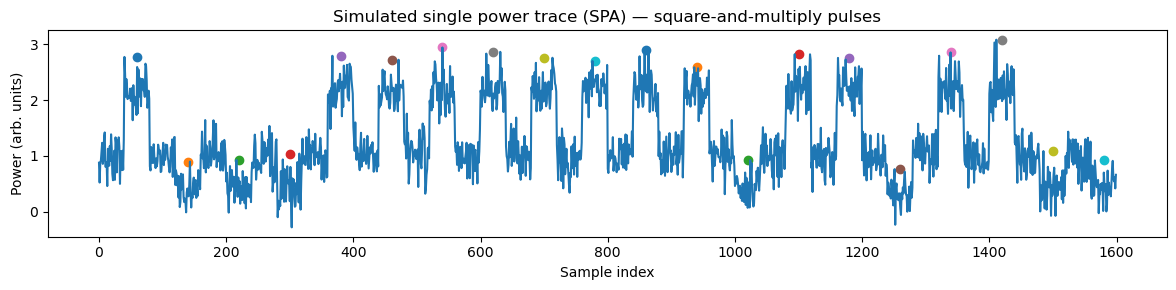

True bits:      10001111111101101100
Extracted bits: 10001111111101101100
Accuracy: 100.00%


In [181]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
from statistics import mean

np.random.seed(420)
random.seed(69)

NUM_BITS = 20
SAMPLES_PER_OP = 40        
SQUARE_AMPLITUDE = 1.0     
MULTIPLY_AMPLITUDE = 2.2   
NOISE_STD = 0.25           
JITTER_MS = 0.0            


d_bits = [random.choice([0,1]) for _ in range(NUM_BITS)]
d_bits[0] = 1

trace = []
op_map = []
for bit in d_bits:
    #Square
    square_segment = np.ones(SAMPLES_PER_OP) * SQUARE_AMPLITUDE
    trace.extend(square_segment.tolist())
    op_map.append(('S', len(trace)-SAMPLES_PER_OP, len(trace)))
    # Multiplication
    if bit == 1:
        mult_segment = np.ones(SAMPLES_PER_OP) * MULTIPLY_AMPLITUDE
        trace.extend(mult_segment.tolist())
        op_map.append(('M', len(trace)-SAMPLES_PER_OP, len(trace)))
    else:
        idle_segment = np.ones(SAMPLES_PER_OP) * 0.4
        trace.extend(idle_segment.tolist())
        op_map.append(('I', len(trace)-SAMPLES_PER_OP, len(trace)))

trace = np.array(trace, dtype=float)

# Optional
if JITTER_MS > 0:
    pass

# Add Gaussian noise
noise = np.random.normal(0, NOISE_STD, size=trace.shape)
noisy_trace = trace + noise

samples_per_bit = SAMPLES_PER_OP * 2  # S + M/I
num_bits_extracted = len(noisy_trace) // samples_per_bit
extracted_bits = []
bit_scores = []

threshold = (MULTIPLY_AMPLITUDE + 0.4) / 2.0

for i in range(num_bits_extracted):
    start = i * samples_per_bit
    mid = start + SAMPLES_PER_OP  # multiply window starts here
    mult_window = noisy_trace[mid: mid + SAMPLES_PER_OP]
    peak = np.max(mult_window)
    bit_guess = 1 if peak > threshold else 0
    extracted_bits.append(bit_guess)
    bit_scores.append({'bit_index': i, 'peak': float(peak), 'threshold': threshold, 'guess': bit_guess, 'true': d_bits[i]})

# prepare dataframe for display
df = pd.DataFrame(bit_scores)

plt.figure(figsize=(12,3))
plt.plot(noisy_trace)
plt.title("Simulated single power trace (SPA) — square-and-multiply pulses")
plt.xlabel("Sample index")
plt.ylabel("Power (arb. units)")
for i in range(num_bits_extracted):
    mid = i * samples_per_bit + SAMPLES_PER_OP + SAMPLES_PER_OP//2
    guess = extracted_bits[i]
    true = d_bits[i]
    marker = 'o' if guess==true else 'x'
    plt.scatter([mid], [np.max(noisy_trace[i*samples_per_bit + SAMPLES_PER_OP: i*samples_per_bit + 2*SAMPLES_PER_OP])], marker=marker)
plt.tight_layout()
plt.show()

print("True bits:     ", "".join(map(str, d_bits)))
print("Extracted bits:", "".join(map(str, extracted_bits)))
print("Accuracy: {:.2f}%".format(100.0 * sum(1 for a,b in zip(d_bits, extracted_bits) if a==b) / len(d_bits)))
